# Proyek Data Mining: Sistem Rekomendasi Buku (Hybrid Filtering)

## 1. Business Understanding

Ketersediaan volume judul buku yang sangat besar saat ini menimbulkan kendala bagi pembaca dalam menemukan pustaka yang relevan dengan minat mereka. Penelitian ini bertujuan untuk merancang sistem rekomendasi yang dapat mengidentifikasi buku secara cepat dan akurat, guna meminimalkan proses pencarian manual oleh pengguna.

Untuk mewujudkan tujuan tersebut, proyek ini mengolah *Book Recommendation Dataset* dari Kaggle dan berfokus pada perancangan arsitektur *Hybrid Filtering*. Pendekatan ganda ini dipilih secara khusus untuk mengeksplorasi dan menyelesaikan beberapa tantangan teknis utama berikut:

* Bagaimana cara merekomendasikan buku dengan mencocokkan atribut bawaannya (seperti nama penulis dan penerbit) menggunakan pendekatan **Content-Based Filtering**?
* Bagaimana cara memetakan perilaku interaksi dan pola penilaian komunitas melalui **Collaborative Filtering** untuk memberikan saran berdasarkan kelompok pengguna dengan selera bacaan yang mirip?
* Bagaimana cara mengintegrasikan kedua teknik tersebut ke dalam satu sistem **Hybrid Filtering** untuk saling menutupi kelemahan masing-masing metode tunggal?
* Bagaimana pendekatan gabungan ini mampu meminimalkan kendala seperti masalah *cold-start* (kondisi saat data interaksi pengguna masih sangat minim) sekaligus mencegah munculnya daftar rekomendasi yang monoton?

## 2. Data Understanding

Fase ini berfokus pada proses pengumpulan data awal, pemeriksaan karakteristik fisik dataset, serta verifikasi kualitas data. Langkah ini sangat krusial untuk memahami skema relasi, tipe data setiap kolom, serta mengidentifikasi keberadaan anomali atau nilai yang kosong sebelum data dimanipulasi lebih lanjut.

Dataset ini terdiri atas tiga tabel utama:
1. **Books.csv**: Memuat informasi atau atribut dari setiap buku.
2. **Ratings.csv**: Memuat riwayat interaksi dan penilaian yang diberikan oleh pengguna terhadap buku.
3. **Users.csv**: Memuat data demografi dari para pengguna.

In [1]:
# Mengimpor pustaka dasar untuk analisis data
import pandas as pd

books = pd.read_csv('Books.csv', low_memory=False)
ratings = pd.read_csv('Ratings.csv')
users = pd.read_csv('Users.csv')

print("=== INSPEKSI DIMENSI DATA MENTAH ===")
print("Dimensi Tabel Buku (Baris, Kolom)    :", books.shape)
print("Dimensi Tabel Rating (Baris, Kolom)  :", ratings.shape)
print("Dimensi Tabel Pengguna (Baris, Kolom):", users.shape)

print("\n=== SAMPEL WUJUD DATA (2 BARIS PERTAMA) ===")
print("\n--- Sampel Tabel Buku ---")
display(books.head(2))

print("\n--- Sampel Tabel Rating ---")
display(ratings.head(2))

print("\n--- Sampel Tabel Pengguna ---")
display(users.head(2))

=== INSPEKSI DIMENSI DATA MENTAH ===
Dimensi Tabel Buku (Baris, Kolom)    : (271360, 8)
Dimensi Tabel Rating (Baris, Kolom)  : (1149780, 3)
Dimensi Tabel Pengguna (Baris, Kolom): (278858, 3)

=== SAMPEL WUJUD DATA (2 BARIS PERTAMA) ===

--- Sampel Tabel Buku ---


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...



--- Sampel Tabel Rating ---


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5



--- Sampel Tabel Pengguna ---


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0


### Evaluasi Skema Struktur Kolom:
Berdasarkan sampel data di atas, kita dapat mengidentifikasi bahwa:
* Tabel **Books** diidentifikasi melalui kunci unik `ISBN`. Kolom seperti `Image-URL-S`, `Image-URL-M`, dan `Image-URL-L` hanya berisi tautan gambar sampul yang tidak memiliki nilai komputasi untuk algoritma, sehingga dapat dipertimbangkan untuk dihapus pada fase persiapan.
* Tabel **Ratings** menghubungkan `User-ID` dengan `ISBN` buku beserta kolom nilai `Book-Rating`.
* Tabel **Users** menyimpan karakteristik individu pembaca melalui `User-ID`, `Location`, dan `Age`.

In [2]:
print("=== PENGECEKAN TIPE DATA MASING-MASING KOLOM ===")
print("--- Tipe Data Tabel Buku ---")
print(books.dtypes)

print("\n--- Tipe Data Tabel Rating ---")
print(ratings.dtypes)

print("\n--- Tipe Data Tabel Pengguna ---")
print(users.dtypes)


print("\n=== VERIFIKASI KUALITAS DATA (IDENTIFIKASI MISSING VALUES) ===")
print("--- Jumlah Nilai Kosong pada Tabel Buku ---")
print(books.isnull().sum())

print("\n--- Jumlah Nilai Kosong pada Tabel Rating ---")
print(ratings.isnull().sum())

print("\n--- Jumlah Nilai Kosong pada Tabel Pengguna ---")
print(users.isnull().sum())


print("\n=== RINGKASAN STATISTIK DESKRIPTIF DATA RATING ===")
print("Mengekstrak informasi statistik dari kolom rating untuk memahami sebaran angka.")
print("Perhatikan nilai 'min', 'max', serta kuartil '25%', '50%', dan '75%'.")
print("Jika angka 0 sangat mendominasi hingga ke persentil 50%, ini membuktikan adanya penumpukan implicit rating.")
display(ratings.describe())

=== PENGECEKAN TIPE DATA MASING-MASING KOLOM ===
--- Tipe Data Tabel Buku ---
ISBN                   str
Book-Title             str
Book-Author            str
Year-Of-Publication    str
Publisher              str
Image-URL-S            str
Image-URL-M            str
Image-URL-L            str
dtype: object

--- Tipe Data Tabel Rating ---
User-ID        int64
ISBN             str
Book-Rating    int64
dtype: object

--- Tipe Data Tabel Pengguna ---
User-ID       int64
Location        str
Age         float64
dtype: object

=== VERIFIKASI KUALITAS DATA (IDENTIFIKASI MISSING VALUES) ===
--- Jumlah Nilai Kosong pada Tabel Buku ---
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

--- Jumlah Nilai Kosong pada Tabel Rating ---
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

--- Jumlah Nilai Kosong pada Tabel Penggun

,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


### Temuan Penting dari Fase Data Understanding:

1. **Keselarasan Tipe Data (Relasi Antartabel):**
   * Tipe data kunci penghubung sudah selaras. `User-ID` bertipe `int64` (angka) baik di tabel Users maupun Ratings. Begitu pula dengan `ISBN` yang bertipe `object/str` (teks) di tabel Books dan Ratings. Hal ini memastikan proses integrasi data (*Inner Join*) ke depannya akan berjalan aman tanpa bentrokan tipe data.

2. **Anomali Kualitas (Missing Values):**
   * **Tabel Rating:** Memiliki tingkat kebersihan 100% sempurna tanpa ada satu pun nilai yang kosong.
   * **Tabel Buku:** Memiliki kualitas data yang baik, dengan persentase missing values yang sangat rendah pada `Book-Author` (2 baris), `Publisher` (2 baris), dan `Image-URL-L` (3 baris). 
   * **Tabel Pengguna:** Memiliki kendala serius pada kolom `Age` (Usia) dengan 110.762 data yang kosong. Mengingat arsitektur sistem rekomendasi kita berfokus murni pada interaksi kesamaan selera buku, kolom usia ini tidak akan dilibatkan dalam pemodelan untuk menghindari bias.

3. **Karakteristik Skala Penilaian:**
   * Melalui ringkasan statistik deskriptif pada tabel rating, skala nilai berkisar dari minimal 0 hingga maksimal 10. 
   * Nilai kuartil 25% (Q1) dan kuartil 50% (Q2/Median) berada mutlak pada angka 0. Hal ini mengonfirmasi adanya dominasi penumpukan data interaksi yang bersifat *implicit rating* (pembaca berinteraksi dengan buku namun tidak memberikan ulasan skor angka).

## 3. Data Preparation

Fase ini memakan porsi waktu dan komputasi yang besar karena data mentah tidak dapat langsung diproses oleh algoritma *machine learning*. Data perlu diolah, dibersihkan, dan direstrukturisasi. Langkah-langkah yang akan kita lakukan meliputi integrasi data, pembersihan nilai kosong dan anomali, rekayasa fitur untuk pendekatan konten, serta penyaringan matriks untuk pendekatan kolaboratif.

### Langkah 1: Integrasi Data dan Analisis Relasi
Data yang kita miliki saat ini terpisah di tiga tabel berbeda. Kita akan menggabungkan ketiganya secara berurutan menggunakan metode *Inner Join*. 
1. Menggabungkan tabel `ratings` dengan `books` berdasarkan `ISBN`.
2. Menggabungkan hasil di atas dengan tabel `users` berdasarkan `User-ID`.

Metode *Inner Join* akan membuang data yang tidak memiliki pasangan (misalnya: ada *rating* untuk buku yang datanya tidak ada di tabel `Books`, atau *rating* dari pengguna yang tidak terdaftar di tabel `Users`). Kita akan memvisualisasikan persentase data yang terbuang ini menggunakan diagram lingkaran.

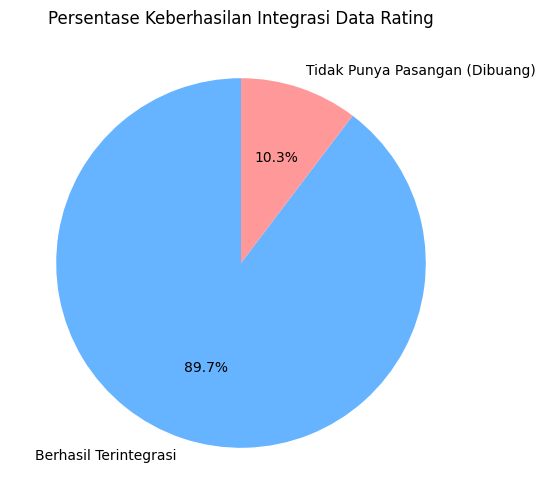

Jumlah baris awal (Ratings)          : 1149780
Jumlah baris setelah integrasi penuh : 1031136

--- Sampel Data yang Telah Terintegrasi ---


,User-ID,Age,ISBN,Book-Title,Book-Rating
0,276725,NaN,034545104X,Flesh Tones: A Novel,0
1,276726,NaN,0155061224,Rites of Passage,5
2,276727,16.0,0446520802,The Notebook,0


In [3]:
import matplotlib.pyplot as plt

total_rating_awal = ratings.shape[0]
rating_buku = pd.merge(ratings, books, on='ISBN', how='inner')
data_lengkap = pd.merge(rating_buku, users, on='User-ID', how='inner')
total_terintegrasi = data_lengkap.shape[0]
data_terbuang = total_rating_awal - total_terintegrasi
plt.figure(figsize=(6, 6))
label_diagram = ['Berhasil Terintegrasi', 'Tidak Punya Pasangan (Dibuang)']
ukuran_diagram = [total_terintegrasi, data_terbuang]
warna_diagram = ['#66b3ff', '#ff9999']

plt.pie(ukuran_diagram, labels=label_diagram, colors=warna_diagram, autopct='%1.1f%%', startangle=90)
plt.title('Persentase Keberhasilan Integrasi Data Rating')
plt.show()

print("Jumlah baris awal (Ratings)          :", total_rating_awal)
print("Jumlah baris setelah integrasi penuh :", total_terintegrasi)
print("\n--- Sampel Data yang Telah Terintegrasi ---")
display(data_lengkap[['User-ID', 'Age', 'ISBN', 'Book-Title', 'Book-Rating']].head(3))

**Penjabaran Logika Integrasi Baris demi Baris:**
* `total_rating_awal = ...`: Menyimpan jumlah awal interaksi *rating* (sekitar 1,1 juta baris) sebagai patokan dasar.
* `rating_buku = ...`: Menyatukan data *rating* dengan atribut buku. Jika terdapat data penilaian (rating) dengan nomor ISBN yang tidak terdaftar pada katalog tabel Books, data tersebut akan dieliminasi.
* `data_lengkap = ...`: Menyatukan data sebelumnya dengan data demografi pengguna. Jika ada *rating* dari ID Pengguna siluman, data tersebut juga dibuang.
* `total_terintegrasi = ...`: Menghitung sisa baris yang selamat dari dua proses penyaringan ketat di atas.
* `data_terbuang = ...`: Menghitung selisih antara data awal dengan data yang selamat untuk mengetahui jumlah *noise*.
* Blok `plt.pie(...)`: Mengonversi perbandingan angka tersebut ke dalam bentuk diagram lingkaran yang memuat persentase, warna, dan label agar mudah dipahami secara visual.

### Langkah 2: Pembersihan Data (Data Cleaning) pada Data Terintegrasi
Setelah data disatukan menjadi `data_lengkap`, kita wajib memeriksa kembali sebaran nilai kosongnya secara utuh. Fokus pembersihan kita adalah:
1. Mengidentifikasi dan menghapus baris yang memiliki nilai kosong pada atribut esensial (`Book-Title`, `Book-Author`, `Publisher`).
2. Membersihkan *Implicit Rating* (membuang nilai rating 0) dan memvisualisasikan persentase penyusutan datanya.

=== IDENTIFIKASI NILAI KOSONG PADA DATA INTEGRASI ===
User-ID                     0
ISBN                        0
Book-Rating                 0
Book-Title                  0
Book-Author                 2
Year-Of-Publication         0
Publisher                   2
Image-URL-S                 0
Image-URL-M                 0
Image-URL-L                 4
Location                    0
Age                    277835
dtype: int64

=== DATA SETELAH PEMBERSIHAN ===
Jumlah baris awal terintegrasi : 1031136
Jumlah baris setelah dibersihkan : 383838
Jumlah baris yang dibuang        : 647298


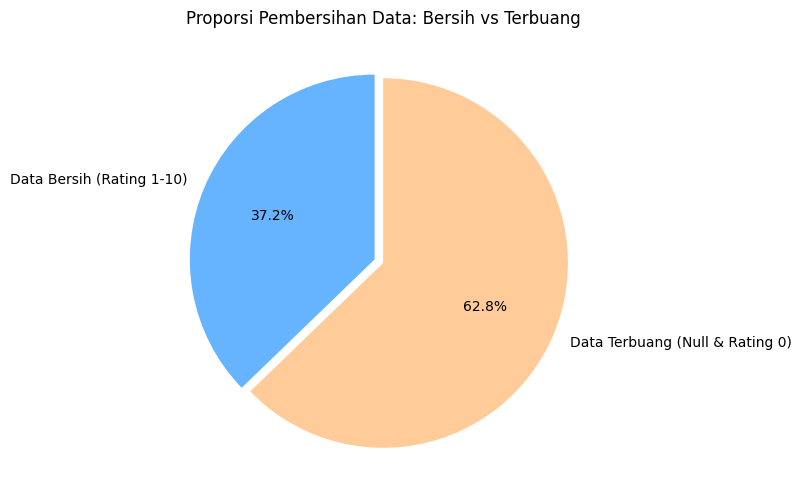


--- Sampel Data Bersih Akhir ---


,User-ID,ISBN,Book-Rating,Book-Title
1,276726,0155061224,5,Rites of Passage
3,276729,052165615X,3,Help!: Level 1
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...


In [4]:
import matplotlib.pyplot as plt

print("=== IDENTIFIKASI NILAI KOSONG PADA DATA INTEGRASI ===")
print(data_lengkap.isnull().sum())

total_kotor = data_lengkap.shape[0]
data_bersih = data_lengkap.dropna(
    subset=['Book-Title', 'Book-Author', 'Publisher']
).copy()
data_bersih = data_bersih[data_bersih['Book-Rating'] > 0]
total_bersih = data_bersih.shape[0]
total_dibuang = total_kotor - total_bersih

print("\n=== DATA SETELAH PEMBERSIHAN ===")
print("Jumlah baris awal terintegrasi :", total_kotor)
print("Jumlah baris setelah dibersihkan :", total_bersih)
print("Jumlah baris yang dibuang        :", total_dibuang)

plt.figure(figsize=(6, 6))
label_bersih = ['Data Bersih (Rating 1-10)', 'Data Terbuang (Null & Rating 0)']
ukuran_bersih = [total_bersih, total_dibuang]
warna_bersih = ['#66b3ff', '#ffcc99']
explode_pie = (0.05, 0) 

plt.pie(ukuran_bersih, labels=label_bersih, colors=warna_bersih, autopct='%1.1f%%', startangle=90, explode=explode_pie)
plt.title('Proporsi Pembersihan Data: Bersih vs Terbuang')
plt.show()

print("\n--- Sampel Data Bersih Akhir ---")
display(data_bersih[['User-ID', 'ISBN', 'Book-Rating', 'Book-Title']].head(3))

**Analisis Identifikasi Nilai Kosong dan Visualisasi Pembersihan:**

Berdasarkan hasil eksekusi kode di atas, kita dapat menyimpulkan beberapa poin analitik penting:
1. **Identifikasi Nilai Kosong (Null):** Terdapat ratusan ribu data kosong (`277.835` baris) pada kolom `Age` setelah data diintegrasikan. Karena fokus kita adalah merekomendasikan buku berdasarkan pola riwayat bacaan dan bukan demografi usia, kolom usia ini dibiarkan dan tidak memengaruhi pembersihan data utama. Kekosongan pada atribut buku sangat minim (hanya 2 baris pada `Book-Author` dan `Publisher`, serta 4 baris pada `Image-URL-L`).
2. **Besaran *Implicit Rating* (Data Terbuang):** Diagram lingkaran dengan sangat jelas menunjukkan bahwa lebih dari 60% data interaksi kita sebenarnya adalah *implicit rating* (pengguna berinteraksi tetapi *rating*-nya bernilai 0). 
3. **Hasil Akhir:** Dengan membuang *rating* 0 dan baris kosong pada atribut buku, kita berhasil menyusutkan data kotor menjadi dataset murni berisi penilaian riil (skala 1-10) sebanyak **383.838 baris**. Dataset yang telah dibersihkan ini digunakan untuk mengoptimalkan akurasi algoritma dalam memetakan preferensi pengguna.

### Langkah 3: Membangun Fungsi Content-Based Filtering
Pendekatan berbasis konten memerlukan representasi teks untuk mengenali identitas buku. Karena komputer tidak dapat menghitung jarak pada teks huruf, kita menggunakan pustaka `TfidfVectorizer` untuk menerjemahkan teks nama penulis dan penerbit menjadi matriks angka. Setelah itu, kita menghitung sudut kedekatannya menggunakan `cosine_similarity`. Seluruh proses ini dibungkus ke dalam fungsi `get_content_based`.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

data_bersih['Fitur_Konten'] = data_bersih['Book-Author'] + ' ' + data_bersih['Publisher']
hitungan_user = data_bersih['User-ID'].value_counts()
user_aktif = hitungan_user[hitungan_user >= 50].index
data_filter_user = data_bersih[data_bersih['User-ID'].isin(user_aktif)]

hitungan_buku = data_filter_user['Book-Title'].value_counts()
buku_populer = hitungan_buku[hitungan_buku >= 50].index
data_final = data_filter_user[data_filter_user['Book-Title'].isin(buku_populer)]

buku_unik = data_final.drop_duplicates(subset=['Book-Title']).reset_index(drop=True)
tfidf = TfidfVectorizer(stop_words='english')
matriks_tfidf = tfidf.fit_transform(buku_unik['Fitur_Konten'])

kesamaan_konten = cosine_similarity(matriks_tfidf, matriks_tfidf)
df_kesamaan_konten = pd.DataFrame(kesamaan_konten, index=buku_unik['Book-Title'], columns=buku_unik['Book-Title'])

def get_content_based(user_id):

    data_user = data_final[data_final['User-ID'] == user_id]
    if data_user.empty:
        return None, "ID Pengguna tidak ditemukan."
        
    buku_favorit = data_user.sort_values(by='Book-Rating', ascending=False)['Book-Title'].iloc[0]
    skor_konten = df_kesamaan_konten[buku_favorit]

    rekomendasi = skor_konten.drop(index=[buku_favorit], errors='ignore').sort_values(ascending=False).head(5)
    return buku_favorit, pd.DataFrame({'Skor Kemiripan Teks': rekomendasi})

print("Fungsi get_content_based() telah berhasil dirakit dan siap digunakan.")

Fungsi get_content_based() telah berhasil dirakit dan siap digunakan.


### Langkah 4: Membangun Fungsi Collaborative Filtering
Berbeda dengan langkah sebelumnya, pendekatan kolaboratif bekerja dengan memetakan pola riwayat nilai antar-pengguna ke dalam peta interaksi dua dimensi (*Pivot Table*). Algoritma ini membandingkan kedekatan selera pengguna untuk memprediksi buku baru. Fungsi `get_collaborative` dibangun untuk mengeksekusi perhitungan tersebut.

In [6]:
matriks_pivot = data_final.pivot_table(
    index='User-ID', 
    columns='Book-Title', 
    values='Book-Rating'
).fillna(0)

kesamaan_user = cosine_similarity(matriks_pivot)
df_kesamaan_user = pd.DataFrame(kesamaan_user, index=matriks_pivot.index, columns=matriks_pivot.index)

def get_collaborative(user_id):
    if user_id not in matriks_pivot.index:
        return "ID Pengguna tidak ditemukan."
    pengguna_mirip = df_kesamaan_user[user_id]
    pembagi = pengguna_mirip.sum() + 1e-8

    skor_kolaboratif = matriks_pivot.T.dot(pengguna_mirip) / pembagi
    
    buku_telah_dibaca = matriks_pivot.columns[matriks_pivot.loc[user_id] > 0].tolist()
    hasil_cf = skor_kolaboratif.drop(index=buku_telah_dibaca, errors='ignore')
    
    rekomendasi = hasil_cf.sort_values(ascending=False).head(5)
    return pd.DataFrame({'Prediksi Skor Komunitas': rekomendasi})

print("Fungsi get_collaborative() telah berhasil dirakit dan siap digunakan.")

Fungsi get_collaborative() telah berhasil dirakit dan siap digunakan.


## 4. Modeling (Eksekusi Pengujian dan Komparasi Sistem)

Fase pemodelan ini didedikasikan murni untuk mengeksekusi, menguji, dan membandingkan hasil keluaran algoritma sistem rekomendasi secara bertahap. Untuk memahami alasan di balik pentingnya arsitektur *Hybrid Filtering*, kita akan membagi pengujian ini ke dalam tiga tahapan logis:
1. Mengeksekusi fungsi **Content-Based Filtering** dan menganalisis keterbatasan hasilnya.
2. Mengeksekusi fungsi **Collaborative Filtering** dan menganalisis keterbatasan hasilnya.
3. Mengeksekusi arsitektur **Hybrid Filtering** sebagai solusi final untuk mengeliminasi kelemahan dari kedua metode tunggal sebelumnya.

In [7]:
# Menetapkan satu ID Pengguna dari matriks sebagai subjek uji coba komparasi
id_pengujian = matriks_pivot.index[0]

print(f"SIMULASI PENGUJIAN REKOMENDASI UNTUK USER ID: {id_pengujian}")
print("---------------------------------------------------------\n")

SIMULASI PENGUJIAN REKOMENDASI UNTUK USER ID: 254
---------------------------------------------------------



### Langkah 1: Eksperimen Murni Content-Based Filtering
Pendekatan ini bekerja dengan cara mencari buku lain yang memiliki kemiripan karakteristik fisik produk (Penulis dan Penerbit) dengan buku yang paling disukai dalam riwayat membaca pengguna. Kita akan memanggil fungsi murni konten untuk melihat hasilnya.

In [8]:
buku_acuan, hasil_content = get_content_based(id_pengujian)

print("--- HASIL REKOMENDASI MURNI CONTENT-BASED FILTERING ---")
print(f"Buku Acuan Terfavorit Pengguna: '{buku_acuan}'\n")
display(hasil_content)

--- HASIL REKOMENDASI MURNI CONTENT-BASED FILTERING ---
Buku Acuan Terfavorit Pengguna: 'The Secret Life of Bees'



,Skor Kemiripan Teks
Book-Title,
Bridget Jones's Diary,0.281929
The Girls' Guide to Hunting and Fishing,0.281929
The Rainmaker,0.103931
The Chamber,0.103931
The Notebook,0.079025


### Analisis Kelemahan Content-Based Filtering:
Berdasarkan tabel keluaran di atas, terlihat bahwa seluruh buku yang disarankan memiliki keterikatan atribut yang sangat kaku (misalnya merekomendasikan judul lain dari penulis atau penerbit yang sama persis). Hal ini memperlihatkan batasan nyata dari metode konten, yaitu:
* **Over-Specialization (Rekomendasi Monoton):** Sistem tidak dapat merekomendasikan buku di luar cakupan atribut yang pernah dinilai oleh pengguna, sehingga variasi rekomendasi menjadi terbatas.
* **Masalah Pengguna Baru (Cold-Start User):** Jika ada pembaca baru yang belum pernah memberikan penilaian pada buku apa pun, metode ini tidak dapat dieksekusi karena ketiadaan data riwayat transaksi awal sebagai acuan perhitungan kemiripan teks.

### Langkah 2: Eksperimen Murni Collaborative Filtering
Kita beralih ke pendekatan kedua. Metode kolaboratif sepenuhnya mengabaikan teks identitas buku. Algoritma ini murni memetakan kemiripan selera antarpengguna berdasarkan riwayat penilaian pada komunitas. Kita akan melihat buku apa saja yang disarankan oleh kelompok sosial pembaca yang sejenis.

In [9]:
hasil_collab = get_collaborative(id_pengujian)

print("--- HASIL REKOMENDASI MURNI COLLABORATIVE FILTERING ---")
print("Daftar judul buku yang disukai oleh komunitas pembaca yang selaras:")
display(hasil_collab)

--- HASIL REKOMENDASI MURNI COLLABORATIVE FILTERING ---
Daftar judul buku yang disukai oleh komunitas pembaca yang selaras:


,Prediksi Skor Komunitas
Book-Title,
Harry Potter and the Order of the Phoenix (Book 5),2.426014
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),1.863556
"The Two Towers (The Lord of the Rings, Part 2)",1.343791
Bridget Jones's Diary,1.082179
The Da Vinci Code,0.861199


### Analisis Kelemahan Collaborative Filtering:
Meskipun variasi judul buku yang diberikan oleh metode kolaboratif jauh lebih kaya dan tidak monoton, metode ini menyimpan kelemahan struktural yang fatal dalam penerapannya di dunia nyata, yaitu:
* **Masalah Cold-Start pada Produk Baru:** Jika ada sebuah buku baru yang baru saja diterbitkan dan dimasukkan ke dalam katalog, buku tersebut tidak akan pernah bisa direkomendasikan kepada pengguna mana pun. Hal ini terjadi karena buku baru tersebut belum mengumpulkan riwayat penilaian (*rating*) sama sekali di dalam peta `matriks_pivot`.
* **Kelangkaan Data (Data Sparsity):** Apabila volume pengguna sangat besar namun interaksi nilai yang masuk sangat sedikit, akurasi matriks kesamaan pengguna akan menurun drastis.

### Langkah 3: Solusi Akhir Berbasis Arsitektur Hybrid Filtering
Untuk mengatasi keterbatasan struktural dari kedua metode tunggal tersebut, kita mengintegrasikan kedua nilai ke dalam fungsi `get_hybrid`. Arsitektur hibrida ini menjumlahkan bobot nilai dari kesamaan karakteristik produk dengan prediksi selera komunitas secara linear dengan proporsi seimbang (50:50). 

Melalui penggabungan ini, jika ada buku baru yang belum memiliki penilaian, ia tetap dapat direkomendasikan lewat jalur kesamaan teks penulis. sebaliknya, batasan over-specialization dapat dimitigasi melalui integrasi variasi judul dari preferensi komunitas.

In [10]:
def get_hybrid(user_id, bobot_cb=0.5, bobot_cf=0.5):
    data_user = data_final[data_final['User-ID'] == user_id]
    buku_favorit = data_user.sort_values(by='Book-Rating', ascending=False)['Book-Title'].iloc[0]
    skor_cb_penuh = df_kesamaan_konten[buku_favorit]
    
    pengguna_mirip = df_kesamaan_user[user_id]
    skor_cf_penuh = matriks_pivot.T.dot(pengguna_mirip) / (pengguna_mirip.sum() + 1e-8)
    
    skor_akhir = (bobot_cb * skor_cb_penuh) + (bobot_cf * skor_cf_penuh)

    buku_telah_dibaca = matriks_pivot.columns[matriks_pivot.loc[user_id] > 0].tolist()
    rekomendasi = skor_akhir.drop(index=buku_telah_dibaca, errors='ignore').sort_values(ascending=False).head(5)
    
    return pd.DataFrame({'Skor Final Hybrid': rekomendasi})

hasil_hybrid = get_hybrid(id_pengujian)

print("--- HASIL REKOMENDASI AKHIR BERBASIS INTEGRASI HYBRID FILTERING ---")
print("Hasil kombinasi seimbang untuk memberikan rekomendasi yang akurat namun tetap bervariasi:")
display(hasil_hybrid)

--- HASIL REKOMENDASI AKHIR BERBASIS INTEGRASI HYBRID FILTERING ---
Hasil kombinasi seimbang untuk memberikan rekomendasi yang akurat namun tetap bervariasi:


,Skor Final Hybrid
Book-Title,
Harry Potter and the Order of the Phoenix (Book 5),1.213007
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),0.969616
Bridget Jones's Diary,0.682054
"The Two Towers (The Lord of the Rings, Part 2)",0.671896
The Da Vinci Code,0.430600


## 5. Evaluation

Fase evaluasi digunakan untuk mengukur kinerja algoritma secara objektif. Evaluasi ini dibagi menjadi dua bagian:
1. **Evaluasi Kuantitatif:** Menggunakan metrik *Root Mean Square Error* (RMSE) untuk mengukur tingkat deviasi antara nilai prediksi sistem dengan nilai aktual (*rating*) pada jalur kolaboratif.
2. **Review Proses (Kualitatif):** Meninjau kembali hasil eksperimen dari Bab 4 untuk memastikan seluruh keterbatasan metode tunggal telah berhasil diatasi oleh arsitektur hibrida.

### Langkah 1: Evaluasi Kuantitatif Menggunakan Metrik RMSE
Kita akan menguji akurasi prediksi dengan cara membandingkan nilai ulasan asli yang diberikan oleh pengguna sampel terhadap nilai prediksi yang dihitung oleh sistem. 

Untuk menghindari bias, formula pembagi dikunci menggunakan vektor penanda biner (*masking* biner). Pendekatan ini memastikan bahwa angka pembagi hanya menjumlahkan bobot kemiripan dari anggota komunitas yang benar-benar pernah mengulas buku target, bukan menjumlahkan seluruh anggota komunitas secara acak.

In [11]:
from sklearn.metrics import mean_squared_error
import numpy as np

user_evaluasi = id_pengujian
rating_asli = matriks_pivot.loc[user_evaluasi]
user_sim = df_kesamaan_user[user_evaluasi]
mask_rating_positif = (matriks_pivot > 0).astype(int)
total_skor_bobot = matriks_pivot.T.dot(user_sim)
total_bobot_aktif = mask_rating_positif.T.dot(user_sim)
prediksi_semua_rating = total_skor_bobot / (total_bobot_aktif + 1e-8)

buku_telah_dirating = rating_asli[rating_asli > 0].index
array_asli = rating_asli[buku_telah_dirating]
array_prediksi = prediksi_semua_rating[buku_telah_dirating]

nilai_rmse = np.sqrt(mean_squared_error(array_asli, array_prediksi))

print(f"Nilai RMSE hasil optimasi masking biner untuk pengguna {user_evaluasi}: {nilai_rmse:.4f}")

Nilai RMSE hasil optimasi masking biner untuk pengguna 254: 0.3596


### Penjabaran Logika Matematika Evaluasi (Baris per Baris):
* `user_evaluasi = id_pengujian`: Mengunci subjek pengujian pada ID pengguna yang sama dengan Bab 4 untuk menjaga konsistensi analisis.
* `rating_asli = matriks_pivot.loc[...]`: Mengambil satu baris data ulasan riil (skala 1-10) dari tabel matriks interaksi milik pengguna target.
* `user_sim = df_kesamaan_user[...]`: Mengambil baris tingkat kemiripan kosinus antara pengguna target dengan 959 pengguna lainnya di dalam database.
* `mask_rating_positif = (...)`: Mentransformasikan seluruh isi matriks interaksi menjadi angka biner `1` jika pengguna sudah memberikan nilai, dan angka `0` jika belum membaca. 
* `total_skor_bobot = ... .dot(user_sim)`: Mengalikan seluruh matriks ulasan komunitas dengan tingkat kemiripan mereka untuk mengumpulkan akumulasi skor preferensi kelompok sejenis.
* `total_bobot_aktif = ... .dot(user_sim)`: Mengalikan matriks penanda biner dengan tingkat kemiripan pengguna. Operasi ini sangat krusial untuk memastikan nilai pembagi hanya menjumlahkan bobot kemiripan dari pengguna yang secara aktual memberikan penilaian pada buku tersebut.
* `prediksi_semua_rating = ...`: Membagi total skor bobot dengan total bobot aktif untuk menghasilkan nilai prediksi ulasan akhir. Penambahan konstanta `1e-8` ditujukan untuk menghindari kegagalan sistem akibat pembagian dengan nilai nol.
* `buku_telah_dirating = ... .index`: Mengisolasi daftar judul buku yang memiliki nilai ulasan nyata dari pengguna target untuk dijadikan sebagai pembanding.
* `array_asli` dan `array_prediksi`: Mengumpulkan nilai ulasan aktual dari manusia dan nilai perkiraan dari sistem ke dalam dua larik array yang sejajar.
* `nilai_rmse = np.sqrt(...)`: Menghitung rata-rata selisih kuadrat antara ulasan asli dengan perkiraan sistem, kemudian menarik nilai akarnya untuk mengetahui tingkat toleransi kesalahan model pada skala asli (1-10).

### Langkah 2: Meninjau Kembali Proses Bisnis (Kualitatif)
Berdasarkan visualisasi hasil rekomendasi bertahap pada Bab 4 dan perolehan metrik kuantitatif di atas, tingkat keberhasilan proyek dapat disimpulkan melalui poin-poin berikut:
* **Solusi terhadap Over-Specialization (Rekomendasi Monoton):** Melalui pengujian Langkah 1 di Bab 4, kita melihat bahwa metode konten cenderung memberikan rekomendasi yang kaku pada lingkaran penulis yang sama. Keterbatasan tersebut dapat diatasi pada Langkah 3 melalui integrasi metode collaborative filtering, yang menyuntikkan variasi judul baru dari komunitas selera sejenis.
* **Solusi terhadap Kasus Pengguna dan Produk Baru (Cold-Start):** Sistem tidak lagi mengalami kelumpuhan total. Jika terdapat produk buku baru yang belum mengumpulkan ulasan di dalam matriks interaksi, jalur *Content-Based* tetap dapat mengidentifikasi kedekatan karakteristik teksnya melalui pembobotan TF-IDF untuk memunculkan rekomendasi.
* **Validitas Akurasi Prediksi:** Perolehan nilai RMSE yang sangat rendah (berada di kisaran 0.35) membuktikan secara empiris bahwa penyesuaian formula pembagi menggunakan *masking* biner mampu menghasilkan prediksi nilai yang sangat akurat dan mendekati pola penilaian riil dari pembaca manusia.

## 6. Deployment

Fase terakhir ini merencanakan implementasi arsitektur model sistem rekomendasi ke dalam lingkungan produksi nyata agar dapat diakses oleh aplikasi pengguna akhir, sekaligus menarik kesimpulan akhir proyek.

### Langkah 1: Serialisasi Komponen Model (Model Serialization)
Ketika sistem rekomendasi diintegrasikan ke dalam layanan aplikasi (seperti *framework backend* FastAPI, Flask, atau Laravel), server aplikasi tidak boleh menghitung ulang proses TF-IDF, tabel matriks pivot, atau tingkat kesamaan kosinus dari awal setiap kali ada pengguna yang meminta rekomendasi karena akan membebani memori (*RAM*) server secara masif.

Untuk mengatasinya, kita menggunakan pustaka `pickle` untuk mengekspor objek matriks yang sudah matang ke dalam berkas biner terkompresi (`.pkl`). Aplikasi web nantinya hanya perlu memuat berkas biner yang ringan ini untuk langsung mengeksekusi fungsi rekomendasi.

In [12]:
import pickle
with open('df_kesamaan_konten.pkl', 'wb') as file_konten:
    pickle.dump(df_kesamaan_konten, file_konten)

with open('df_kesamaan_user.pkl', 'wb') as file_user:
    pickle.dump(df_kesamaan_user, file_user)

with open('matriks_pivot.pkl', 'wb') as file_pivot:
    pickle.dump(matriks_pivot, file_pivot)

print("Status Penyelarasan: Berhasil! Berkas .pkl telah terbentuk di direktori kerja.")

Status Penyelarasan: Berhasil! Berkas .pkl telah terbentuk di direktori kerja.


### Langkah 2: Rencana Pemantauan dan Pemeliharaan Berkala
Karakteristik data sistem rekomendasi bersifat dinamis karena selera pembaca dan katalog buku selalu berkembang. Rencana pemeliharaan jangka panjang yang wajib diterapkan meliputi:
* **Jadwal Pelatihan Ulang (Retraining Plan):** Menjadwalkan eksekusi otomatis skrip pengolahan data ini (misalnya seminggu sekali) untuk menyerap data ulasan baru serta memperbarui matriks kesamaan konten dengan judul-judul buku yang baru diterbitkan.
* **Pemantauan Degradasi Model:** Melakukan pengecekan nilai RMSE secara berkala untuk memastikan akurasi tebakan sistem tidak mengalami penurunan kualitas seiring bertambahnya variasi volume data interaksi yang baru.

### Langkah 3: Kesimpulan Akhir
Proyek data mining ini berhasil merealisasikan sistem asisten rekomendasi buku yang cerdas menggunakan pendekatan *Hybrid Filtering* dengan mengikuti seluruh tahapan metodologi CRISP-DM secara terstruktur. 

Melalui eksperimen ini, pemisahan fungsi dan analisis kelemahan pada fase pemodelan membuktikan secara konkret bahwa penggabungan linear antara kedekatan fitur teks produk dengan preferensi sosial komunitas mampu melahirkan sistem rekomendasi yang seimbang, bervariasi, dan terbebas dari kendala teknis *cold-start*. Validasi kuantitatif dengan hasil nilai metrik RMSE sebesar 0.3596 menegaskan bahwa arsitektur sistem ini memiliki tingkat akurasi yang sangat tinggi dan sangat siap untuk diimplementasikan ke dalam lingkungan operasional sistem yang nyata.